<a href="https://colab.research.google.com/github/Sherlysukmadira/2311532015_Sherly-Sukmadira-Putri_ImageProcessing/blob/main/sentimen_pilkada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EKSPLORASI DATA

In [12]:
pip install wordcloud pandas matplotlib


In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv('dataset_tweeter_sentiment_pilkada_DKI_2017.csv')

# Tampilkan 30 baris pertama
df.head(30)




,Id,Sentiment,Pasangan Calon,Text Tweet
0,1,negative,Agus-Sylvi,Banyak akun kloning seolah2 pendukung #agussil...
1,2,negative,Agus-Sylvi,#agussilvy bicara apa kasihan yaa...lap itu ai...
2,3,negative,Agus-Sylvi,Kalau aku sih gak nunggu hasil akhir QC tp lag...
3,4,negative,Agus-Sylvi,Kasian oh kasian dengan peluru 1milyar untuk t...
4,5,negative,Agus-Sylvi,Maaf ya pendukung #AgusSilvy..hayo dukung #Ani...
5,6,negative,Agus-Sylvi,aneh deh lebay masa ini di sangkut pautkan sam...
6,7,negative,Agus-Sylvi,Kepada Allah SWT kami ucapkan rasa syukur dan ...
7,8,negative,Agus-Sylvi,Terima Kasih teruntuk pendukung #AHY #SYLVI ka...
8,9,negative,Agus-Sylvi,Trima Kasih atas KeIstiqomahan Relawan #AHY @A...
9,10,negative,Agus-Sylvi,Mengenang pidato kekalahan #ahy


Data teks mentah mengandung banyak noise seperti hashtag, mention, dan karakter berulang. Oleh karena itu, diperlukan preprocessing untuk meningkatkan kualitas teks agar lebih mudah dianalisis.

In [16]:
len(df)

900

In [32]:
#Cek distribuasi data
df['Sentiment'].value_counts()
df['Pasangan Calon'].value_counts()

,count
Pasangan Calon,
Agus-Sylvi,300
Ahok-Djarot,300
Anies-Sandi,300


Dataset memiliki distribusi yang seimbang (balanced) untuk setiap pasangan calon, di mana masing-masing kandidat memiliki jumlah data yang sama. Hal ini menunjukkan bahwa dataset telah melalui proses kurasi untuk menghindari bias terhadap kandidat tertentu.

In [17]:
#cek missing value
missing_values = df.isnull().sum()
print(missing_values)

# totalkan jumlah missing value
total_missing = missing_values.sum()
print(f"\nTotal missing values in the DataFrame: {total_missing}")

# kalkulasikan persentase missing value
percentage_missing = (total_missing / (df.shape[0] * df.shape[1])) * 100
print(f"Percentage of missing values in the DataFrame: {percentage_missing:.2f}%")


Id                0
Sentiment         0
Pasangan Calon    0
Text Tweet        0
dtype: int64

Total missing values in the DataFrame: 0
Percentage of missing values in the DataFrame: 0.00%


In [33]:
#Cek sebaran sentimen
df.groupby('Pasangan Calon')['Sentiment'].value_counts()

Pasangan Calon  Sentiment
Agus-Sylvi      negative     150
                positive     150
Ahok-Djarot     negative     150
                positive     150
Anies-Sandi     negative     150
                positive     150
Name: count, dtype: int64

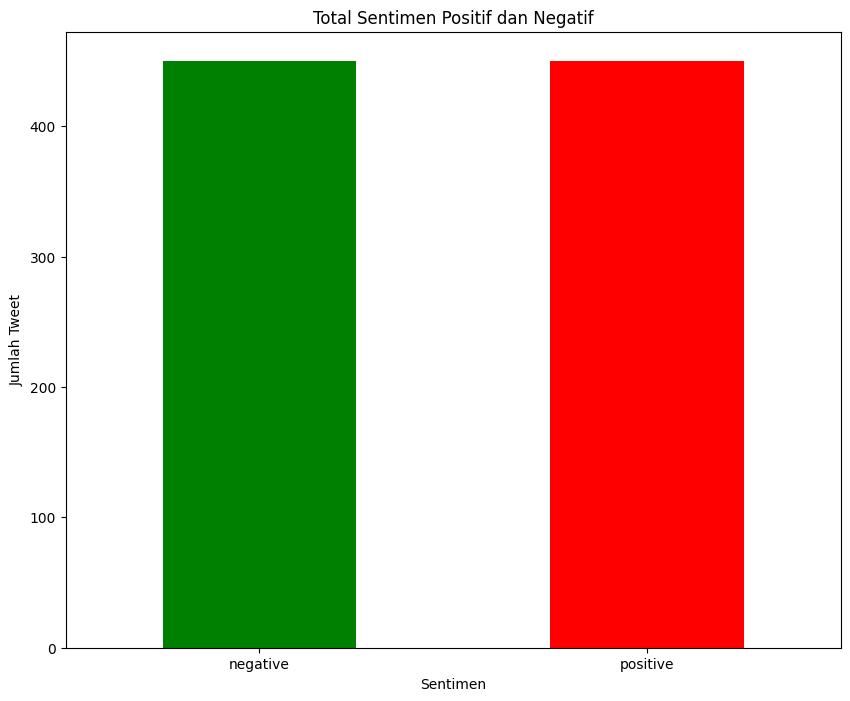

In [44]:

import matplotlib.pyplot as plt
# Calculate the sentiment counts
sentiment_counts = df['Sentiment'].value_counts()

# Create the bar plot
plt.figure(figsize=(10, 8))
sentiment_counts.plot(kind='bar', color=['green', 'red'])  # Customize colors
plt.title('Total Sentimen Positif dan Negatif')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()


In [21]:
#Cek Duplikasi
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


Berdasarkan hasil pengecekan, dataset tidak memiliki missing value pada seluruh kolom. Hal ini menunjukkan bahwa data yang digunakan sudah lengkap dan tidak memerlukan proses penanganan missing value. Dengan demikian, analisis dapat langsung dilanjutkan ke tahap eksplorasi data tanpa perlu melakukan imputasi atau penghapusan data.

# CLEANING TEKS

In [23]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)        # hapus URL
    text = re.sub(r'@\w+', '', text)           # hapus mention
    text = re.sub(r'#\w+', '', text)           # hapus hashtag
    text = re.sub(r'[^a-z\s]', '', text)       # hapus angka & simbol
    text = re.sub(r'(.)\1+', r'\1', text)      # huruf berulang (dammnn → dam)
    text = text.strip()
    return text

df['clean_text'] = df['Text Tweet'].apply(clean_text)

In [22]:
#Cek kata yang paling sering muncul
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(10)

print(word_freq)

[('yang', 222), ('dan', 156), ('face', 153), ('di', 139), ('untuk', 104), ('ahy', 103), ('tidak', 100), ('with', 97), ('ahok', 94), ('jakarta', 87)]


Kata-kata yang sering muncul mencerminkan topik utama yang dibahas masyarakat, seperti isu politik, kandidat, dan sentimen terhadap kebijakan tertentu.Di sini masi terdapat kata hubung. Untuk menangani kata hubung ini,kita lakukan stopword removal

In [24]:
#Stopword Removal
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [25]:
#Cek kembali kata yang paling sering muncul
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(10)

print(word_freq)

[('face', 153), ('ahy', 103), ('with', 97), ('ahok', 94), ('jakarta', 87), ('pilkada', 86), ('hand', 85), ('dki', 73), ('ya', 62), ('menang', 62)]


Ditemukan bahwa beberapa kata seperti “face” dan “hand” muncul akibat proses konversi emoji selama preprocessing. Oleh karena itu, dilakukan penyesuaian dengan menambahkan kata-kata tersebut ke dalam daftar stopword agar tidak mempengaruhi hasil analisis.

In [28]:
# stopword Indonesia & Inggris
stop_words_id = set(stopwords.words('indonesian'))
stop_words_en = set(stopwords.words('english'))

# gabungkan
all_stopwords = stop_words_id.union(stop_words_en)

# tambah custom
custom_stopwords = {'face', 'with', 'hand', 'ya', 'yg', 'aja', 'nya'}

all_stopwords = all_stopwords.union(custom_stopwords)

In [29]:
def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in all_stopwords]
    return ' '.join(filtered)

In [30]:
df['clean_text'] = df['clean_text'].apply(remove_stopwords)


In [31]:
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(10)

print(word_freq)

[('ahy', 103), ('ahok', 94), ('jakarta', 87), ('pilkada', 86), ('dki', 73), ('menang', 62), ('smiling', 61), ('kalah', 56), ('anies', 53), ('aniesandi', 48)]


Kata-kata yang paling sering muncul menunjukkan bahwa diskusi publik berpusat pada kandidat utama (Ahok, Anies, dan AHY) serta konteks Pilkada DKI Jakarta.

In [37]:
#Bandingkan kata positif dan negatif setelah data dibersihkan
pos_words = ' '.join(df[df['Sentiment']=='positive']['clean_text']).split()
neg_words = ' '.join(df[df['Sentiment']=='negative']['clean_text']).split()

print(pos_words[:10])   # tampilkan 10 kata pertama
print(neg_words[:10])

['doa', 'ku', 'semoga', 'suaranya', 'mas', 'agusylvi', 'beneran', 'mas', 'agus', 'mu']
['akun', 'kloning', 'pendukung', 'menyerang', 'paslon', 'opini', 'argumen', 'pmbenaranjangan', 'terkecoh', 'bicara']


Sentimen positif cenderung menggunakan kata-kata yang bersifat dukungan dan harapan, seperti “doa” dan “semoga”. Hal ini menunjukkan bahwa pengguna mengekspresikan dukungan secara personal dan emosional.

Sebaliknya, sentimen negatif didominasi oleh kata-kata yang berkaitan dengan konflik dan perdebatan, seperti “menyerang”, “argumen”, dan “akun kloning”, yang mengindikasikan adanya dinamika diskusi yang lebih kritis dan konfrontatif.

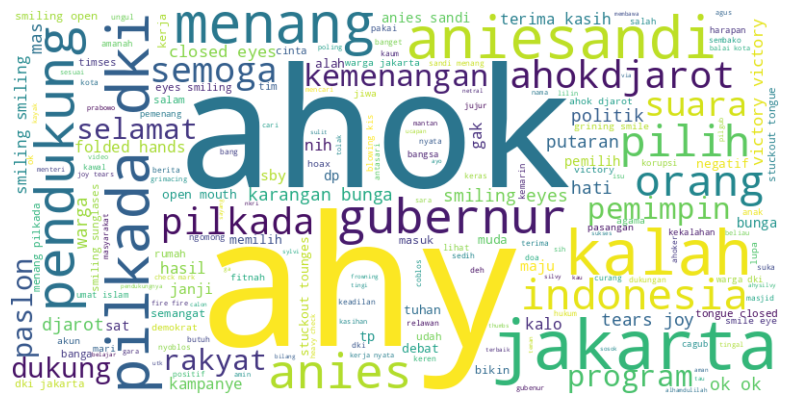

In [39]:
#Cek wordcloud keseluruhan sentimen (positif dan negatif)

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Gabungkan semua text tweet jadi satu string
text = " ".join(df['clean_text'])

# Generate wordcloud dari text tweet
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)

# Tampilkan wordcloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


WordCloud menunjukkan bahwa diskusi publik berfokus pada tiga kandidat utama serta konteks Pilkada DKI Jakarta. Kata “menang” dan “kalah” yang cukup dominan mengindikasikan bahwa percakapan banyak membahas kompetisi dan hasil pemilihan.

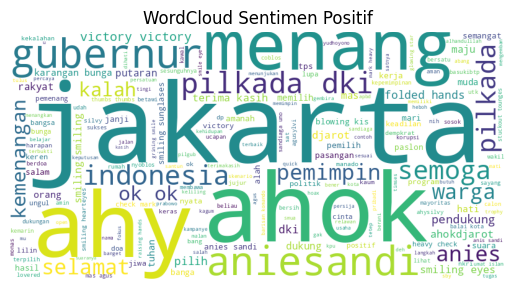

In [40]:
#CEk word cloud sentimen positif
text_pos = ' '.join(df[df['Sentiment']=='positive']['clean_text'])

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.imshow(wc_pos)
plt.title("WordCloud Sentimen Positif")
plt.axis('off')
plt.show()

Sentimen positif didominasi oleh kata-kata yang bersifat harapan dan dukungan seperti “semoga”, “selamat”, dan “menang”. Hal ini menunjukkan bahwa pengguna media sosial cenderung mengekspresikan dukungan secara optimis terhadap kandidat tertentu.

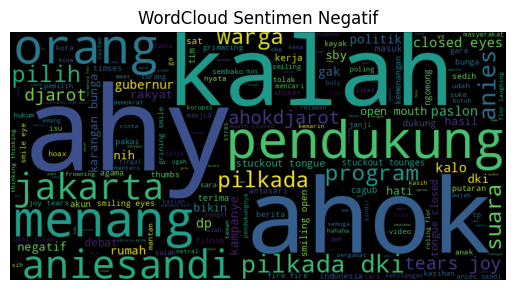

In [42]:
#CEk word cloud sentimen negatif
text_neg = ' '.join(df[df['Sentiment']=='negative']['clean_text'])

wc_neg = WordCloud(width=800, height=400, background_color='black').generate(text_neg)

plt.imshow(wc_neg)
plt.title("WordCloud Sentimen Negatif")
plt.axis('off')
plt.show()

Sentimen negatif lebih banyak mengandung kata-kata yang berkaitan dengan konflik dan dinamika politik, seperti “pendukung” dan “politik”. Hal ini menunjukkan bahwa opini negatif cenderung muncul dalam konteks perdebatan atau perbedaan pandangan antar kelompok.

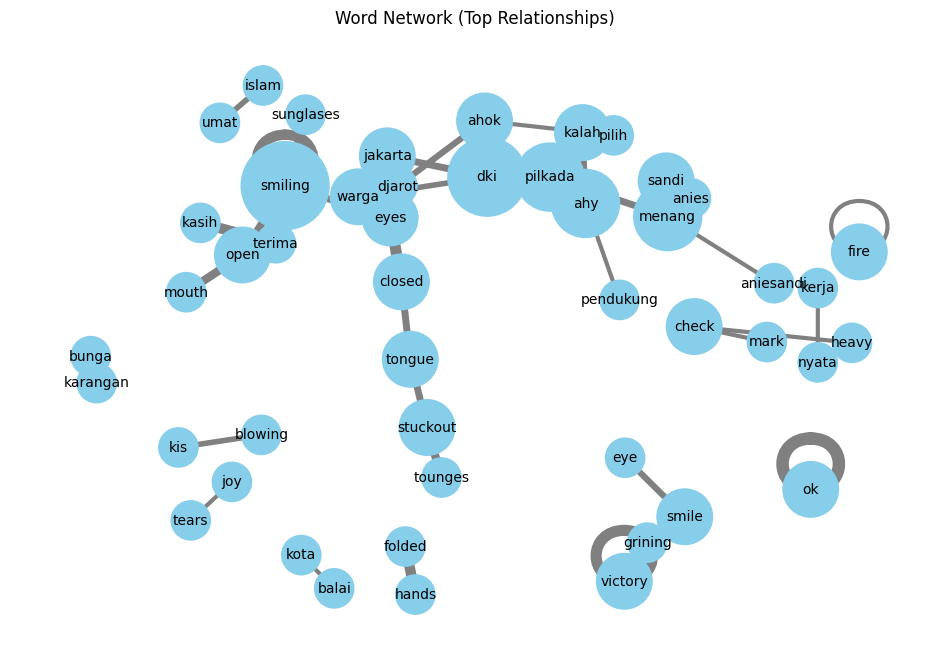

In [50]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import bigrams

# 1. Ambil kata dari clean_text
words = ' '.join(df['clean_text']).split()

# 2. Buat bigram (pasangan kata)
bigram_list = list(bigrams(words))

# 3. Hitung frekuensi
bigram_freq = Counter(bigram_list)

# 4. Ambil top N biar ga penuh
top_n = 40
top_bigrams = bigram_freq.most_common(top_n)

# 5. Buat graph
G = nx.Graph()

for (w1, w2), freq in top_bigrams:
    G.add_edge(w1, w2, weight=freq)

# 6. Hitung degree (penting buat ukuran node)
degree_dict = dict(G.degree())

# 7. Scaling node size
node_size = [v * 800 for v in degree_dict.values()]

# 8. Scaling edge width
edge_width = [G[u][v]['weight'] * 0.5 for u, v in G.edges()]

# 9. Layout (biar ga numpuk)
pos = nx.spring_layout(G, k=0.8, seed=42)

# 10. Plot
plt.figure(figsize=(12,8))

nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Word Network (Top Relationships)")
plt.axis('off')
plt.show()

Hasil visualisasi jaringan kata menunjukkan bahwa kata “smiling” menjadi node paling dominan, yang disebabkan oleh tingginya penggunaan emoji dalam data media sosial. Meskipun demikian, kata-kata yang berkaitan dengan konteks politik seperti “dki”, “pilkada”, “ahy”, dan “ahok” tetap membentuk struktur utama jaringan. Selain itu, kemunculan kata “kalah” dan “pilih” menunjukkan bahwa percakapan publik banyak berfokus pada hasil pemilihan dan preferensi pemilih. Temuan ini mengindikasikan bahwa data media sosial tidak hanya mencerminkan diskusi substantif, tetapi juga ekspresi emosional pengguna yang dapat mempengaruhi hasil analisis.

Analisis :

- Dari pola ini, bisa disimpulkan bahwa percakapan di Twitter mengenai Pilkada DKI 2017 lebih banyak memiliki nada positif dibandingkan negatif.
-Ahok-Djarot memiliki total tweet yang paling banyak dibanding pasangan lain. Ini bisa menunjukkan bahwa mereka mendapatkan lebih banyak perhatian di media sosial.

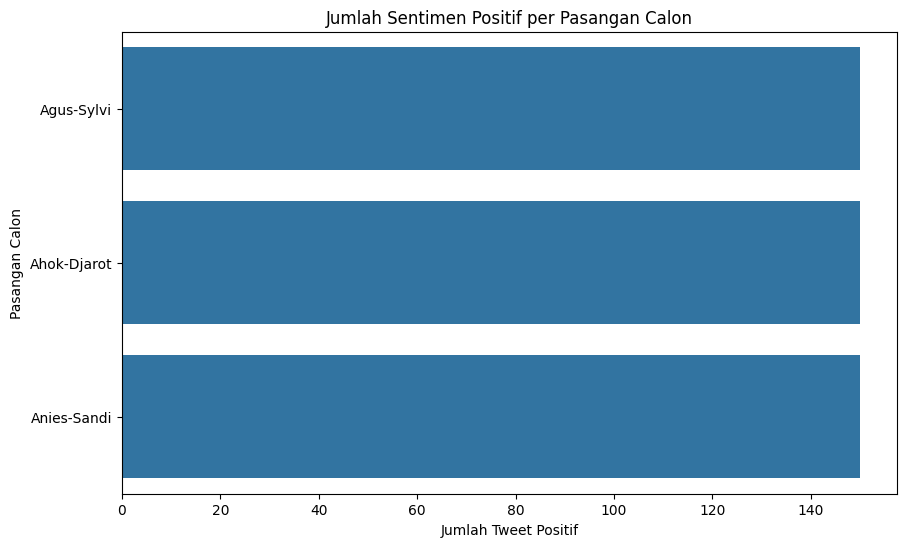

In [55]:
# 1. Pastikan format sentiment konsisten
df['Sentiment'] = df['Sentiment'].str.lower()

# 2. Filter data positif
positif_df = df[df['Sentiment'] == 'positive']

# 3. Hitung jumlah per pasangan calon
positif_per_paslon = positif_df['Pasangan Calon'].value_counts()

# 4. Visualisasi
plt.figure(figsize=(10, 6))

sns.barplot(
    x=positif_per_paslon.values,
    y=positif_per_paslon.index
)

plt.title('Jumlah Sentimen Positif per Pasangan Calon')
plt.xlabel('Jumlah Tweet Positif')
plt.ylabel('Pasangan Calon')

plt.show()

Top 10 Positive Words: {'gubernur', 'menang', 'pemimpin', 'dki', 'ahok', 'jakarta', 'smiling', 'victory', 'anies', 'aniesandi', 'indonesia', 'pilkada', 'ok', 'ahy', 'semoga'}
Top 10 Negative Words: {'pilih', 'eyes', 'stuckout', 'dki', 'ahok', 'jakarta', 'aniesandi', 'smiling', 'anies', 'kalah', 'orang', 'pendukung', 'pilkada', 'menang', 'ahy'}


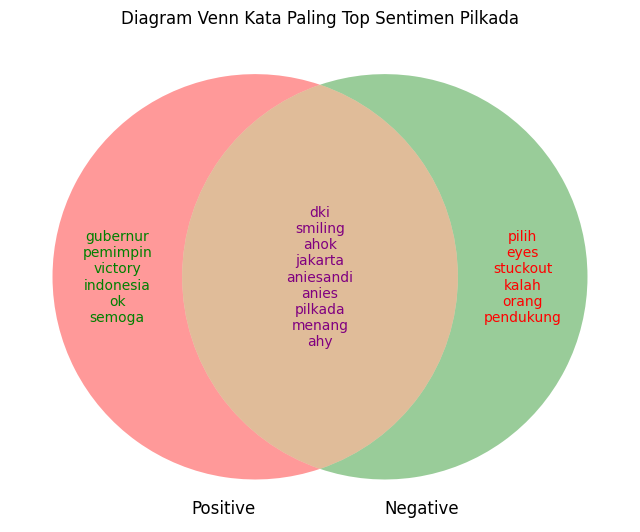

In [57]:

from matplotlib_venn import venn2
from collections import Counter

# 1. Pastikan format sentiment konsisten
df['Sentiment'] = df['Sentiment'].str.lower()

# 2. Gunakan teks yang sudah dibersihkan (WAJIB)
positive_tweets = df[df['Sentiment'] == 'positive']['clean_text']
negative_tweets = df[df['Sentiment'] == 'negative']['clean_text']

# 3. Fungsi ambil top words
def get_top_words(tweets, top_n=10):
    words = []
    for tweet in tweets.dropna():
        tokens = tweet.split()
        words.extend(tokens)
    word_counts = Counter(words)
    return set([word for word, count in word_counts.most_common(top_n)])

# 4. Ambil top 10 kata
positive_top_words = get_top_words(positive_tweets, top_n=15)
negative_top_words = get_top_words(negative_tweets, top_n=15)

# 5. Print hasil
print("Top 10 Positive Words:", positive_top_words)
print("Top 10 Negative Words:", negative_top_words)

# 6. Buat Venn Diagram
plt.figure(figsize=(8,8))
venn = venn2([positive_top_words, negative_top_words], ('Positive', 'Negative'))

# 7. Handle kalau label kosong (biar ga error)
if venn.get_label_by_id('10'):
    venn.get_label_by_id('10').set_text('\n'.join(positive_top_words - negative_top_words))
    venn.get_label_by_id('10').set_color("green")

if venn.get_label_by_id('01'):
    venn.get_label_by_id('01').set_text('\n'.join(negative_top_words - positive_top_words))
    venn.get_label_by_id('01').set_color("red")

if venn.get_label_by_id('11'):
    venn.get_label_by_id('11').set_text('\n'.join(positive_top_words & negative_top_words))
    venn.get_label_by_id('11').set_color("purple")

# 8. Judul
plt.title('Diagram Venn Kata Paling Top Sentimen Pilkada')
plt.show()

Analisis :

1. Kata-kata pada irisan menunjukkan topik utama yang dibahas oleh seluruh pengguna, baik dalam sentimen positif maupun negatif. Fokus utama percakapan adalah kandidat (Ahok, Anies, AHY) serta konteks Pilkada DKI Jakarta. Hal ini menandakan bahwa meskipun opini berbeda, topik diskusi tetap sama.
2. Sentimen positif didominasi oleh kata-kata yang bersifat optimisme dan dukungan, seperti “semoga”, “victory”, dan “pemimpin”. Ini menunjukkan bahwa pengguna cenderung mengekspresikan harapan serta kepercayaan terhadap kandidat dalam bentuk bahasa yang positif dan aspiratif.
3. Sentimen negatif cenderung mengandung kata-kata yang berkaitan dengan konflik sosial dan dinamika antar pendukung, seperti “kalah”, “pendukung”, dan “orang”. Hal ini menunjukkan bahwa opini negatif lebih sering muncul dalam konteks perdebatan, kritik, atau ketidakpuasan.

# Pengolahan data menggunakan Naive Bayes + Logistic Regression

Naive bayes dan logistic regression digunakna untuk memprediksi sentimen baru apakah termasuk ke positif atau negatif

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
#split data
X = df['clean_text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
#Lakukan TF-IDF untuk mengukur seberapa penting sebuah kata  dalam dokumen
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,3),   # sampai trigram
    min_df=2,
    max_df=0.9
)

In [69]:
#Gunakan model SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [70]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=2,
    max_iter=2000,
    class_weight='balanced'
)

lr_model.fit(X_train_tfidf, y_train)
y_pred = lr_model.predict(X_test_tfidf)

# Evaluasi Model

In [72]:
#Akurasi
print("=== Accuracy ===")
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("Logistic Regression:", accuracy_score(y_test, y_pred))

=== Accuracy ===
SVM: 0.7
Logistic Regression: 0.6666666666666666


In [73]:
#classification Report
print("\nSVM Report:\n", classification_report(y_test, y_pred_svm))
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred))


SVM Report:
               precision    recall  f1-score   support

    negative       0.69      0.72      0.71        90
    positive       0.71      0.68      0.69        90

    accuracy                           0.70       180
   macro avg       0.70      0.70      0.70       180
weighted avg       0.70      0.70      0.70       180


Logistic Regression Report:
               precision    recall  f1-score   support

    negative       0.65      0.73      0.69        90
    positive       0.69      0.60      0.64        90

    accuracy                           0.67       180
   macro avg       0.67      0.67      0.67       180
weighted avg       0.67      0.67      0.67       180



Model SVM menunjukkan performa yang cukup baik dengan akurasi 70%. Nilai precision dan recall yang relatif seimbang antara kelas negatif dan positif menunjukkan bahwa model mampu mengklasifikasikan kedua kelas tanpa bias yang signifikan.

sementara model Logistic Regression memiliki performa yang sedikit lebih rendah dibandingkan SVM. Terlihat bahwa model cenderung kurang optimal dalam mendeteksi sentimen positif, yang ditunjukkan oleh nilai recall yang lebih rendah pada kelas positif.

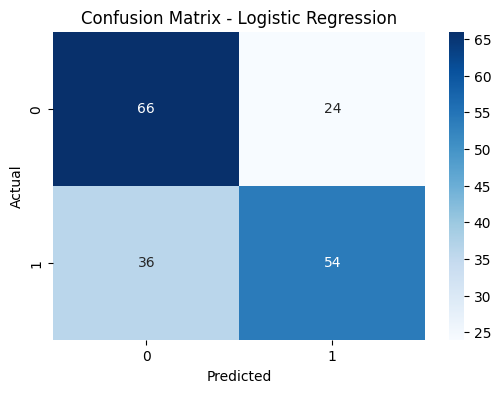

In [74]:
#Cunfussion Matriks Logistig Regression
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

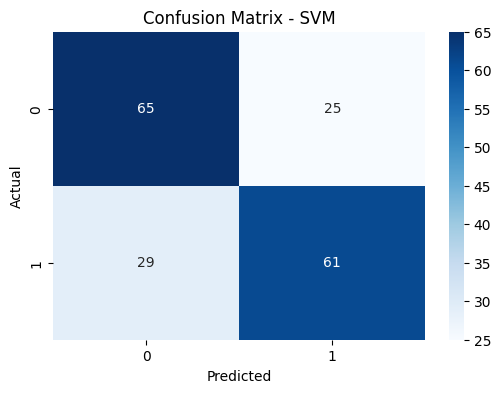

In [75]:
#Cunfussion Matriks  svm
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Confusion matrix menunjukkan bahwa kesalahan klasifikasi pada model Logistic Regression dan svm lebih banyak terjadi pada kelas negatif yang mengindikasikan bahwa model cenderung bias terhadap kelas positif.